# Klasifikasi Kualitas Air Menggunakan Fitur HSV dan Random Forest

Notebook ini mengolah citra kualitas air melalui ekstraksi fitur warna HSV (*Hue, Saturation,* dan *Value*). Hasil ekstraksi digunakan untuk membangun model klasifikasi **Random Forest** dan **Decision Tree** dengan tiga kategori, yaitu **Jernih**, **Keruh**, dan **Kotor**.

Agar jumlah data lebih seimbang dan proses pelatihan lebih ringan, notebook membentuk subset berisi maksimal **1.500 data pada setiap kategori** atau sekitar **4.500 data** secara keseluruhan. Pengambilan subset dilakukan secara acak dan tidak mengubah nilai fitur maupun label data.

## 1. Import Library

Library digunakan untuk membaca citra, mengolah data, menampilkan visualisasi, membangun model, melakukan optimasi hyperparameter, dan mengevaluasi hasil klasifikasi.

In [33]:
import os
import cv2
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
print("Seluruh library berhasil diimpor.")

Seluruh library berhasil diimpor.


## 2. Menentukan Lokasi Dataset

Folder dataset harus memiliki subfolder `Class 1` sampai `Class 5`. Setiap subfolder berisi citra kualitas air yang akan diekstraksi menjadi fitur HSV.

In [2]:
DATASET_PATH = "Dataset_air/Dataset"

LABEL_MAPPING = {
    "Class 1": "Jernih",
    "Class 2": "Jernih",
    "Class 3": "Keruh",
    "Class 4": "Kotor",
    "Class 5": "Kotor"
}

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Folder dataset tidak ditemukan: {DATASET_PATH}\n"
        "Pastikan folder Dataset_air/Dataset berada di lokasi yang sama dengan notebook."
    )

print("Folder dataset:")
print(os.path.abspath(DATASET_PATH))

print("\nSubfolder yang tersedia:")
for nama in sorted(os.listdir(DATASET_PATH)):
    path = os.path.join(DATASET_PATH, nama)
    if os.path.isdir(path):
        print("-", nama)

Folder dataset:
c:\Projek_air_revisi\Dataset_air\Dataset

Subfolder yang tersedia:
- Class 1
- Class 2
- Class 3
- Class 4
- Class 5


## 3. Ekstraksi Fitur HSV

Setiap citra dibaca menggunakan OpenCV, kemudian dikonversi dari BGR menjadi HSV. Dari masing-masing kanal dihitung nilai **mean**, **standar deviasi**, dan **median**, sehingga setiap citra menghasilkan sembilan fitur numerik.

In [3]:
data_hsv = []
gambar_gagal = []

for folder_kelas in sorted(os.listdir(DATASET_PATH)):
    path_kelas = os.path.join(DATASET_PATH, folder_kelas)

    if not os.path.isdir(path_kelas):
        continue

    if folder_kelas not in LABEL_MAPPING:
        print(f"Folder dilewati karena tidak memiliki mapping label: {folder_kelas}")
        continue

    label = LABEL_MAPPING[folder_kelas]

    for nama_file in sorted(os.listdir(path_kelas)):
        if not nama_file.lower().endswith(IMAGE_EXTENSIONS):
            continue

        path_gambar = os.path.join(path_kelas, nama_file)
        gambar = cv2.imread(path_gambar)

        if gambar is None:
            gambar_gagal.append(path_gambar)
            continue

        hsv = cv2.cvtColor(gambar, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)

        data_hsv.append({
            "filename": nama_file,
            "path": path_gambar,
            "kelas_asli": folder_kelas,
            "label": label,
            "H_mean": float(np.mean(h)),
            "S_mean": float(np.mean(s)),
            "V_mean": float(np.mean(v)),
            "H_std": float(np.std(h)),
            "S_std": float(np.std(s)),
            "V_std": float(np.std(v)),
            "H_median": float(np.median(h)),
            "S_median": float(np.median(s)),
            "V_median": float(np.median(v))
        })

df_lengkap = pd.DataFrame(data_hsv)

if df_lengkap.empty:
    raise ValueError("Tidak ada gambar yang berhasil diproses.")

print("Ekstraksi fitur selesai.")
print("Jumlah gambar berhasil diproses:", len(df_lengkap))
print("Jumlah gambar gagal dibaca:", len(gambar_gagal))

Ekstraksi fitur selesai.
Jumlah gambar berhasil diproses: 11518
Jumlah gambar gagal dibaca: 0


## 4. Pemeriksaan Hasil Ekstraksi

Tahap ini menampilkan ukuran dataset, jumlah data pada setiap kelas asli, jumlah data pada setiap label akhir, serta contoh data hasil ekstraksi.

In [4]:
print("Ukuran dataset lengkap:", df_lengkap.shape)

print("\nJumlah data per kelas asli:")
print(df_lengkap["kelas_asli"].value_counts().sort_index())

print("\nJumlah data per label:")
print(df_lengkap["label"].value_counts())

print("\nLima data pertama:")
display(df_lengkap.head())

Ukuran dataset lengkap: (11518, 13)

Jumlah data per kelas asli:
kelas_asli
Class 1    1581
Class 2    2699
Class 3    2788
Class 4    2855
Class 5    1595
Name: count, dtype: int64

Jumlah data per label:
label
Kotor     4450
Jernih    4280
Keruh     2788
Name: count, dtype: int64

Lima data pertama:


,filename,path,kelas_asli,label,H_mean,S_mean,V_mean,H_std,S_std,V_std,H_median,S_median,V_median
0,M0-LBA-AN_frame_0011.jpg,Dataset_air/Dataset\Class 1\M0-LBA-AN_frame_00...,Class 1,Jernih,104.341972,10.038576,169.435608,4.687222,1.561807,6.413139,103.0,11.0,170.0
1,M0-LBA-AN_frame_0023.jpg,Dataset_air/Dataset\Class 1\M0-LBA-AN_frame_00...,Class 1,Jernih,104.193744,10.062212,168.752304,5.940830,1.611004,5.995369,103.0,11.0,169.0
2,M0-LBA-AN_frame_0035.jpg,Dataset_air/Dataset\Class 1\M0-LBA-AN_frame_00...,Class 1,Jernih,105.641564,9.811736,169.458728,4.829188,1.579903,6.354167,103.0,10.0,170.0
3,M0-LBA-AN_frame_0047.jpg,Dataset_air/Dataset\Class 1\M0-LBA-AN_frame_00...,Class 1,Jernih,104.517032,10.033404,169.268404,4.566713,1.533005,5.992928,103.0,11.0,170.0
4,M0-LBA-AN_frame_0059.jpg,Dataset_air/Dataset\Class 1\M0-LBA-AN_frame_00...,Class 1,Jernih,104.189396,10.139732,168.846476,4.604711,1.481013,6.081818,103.0,11.0,169.0


In [5]:
if gambar_gagal:
    print("Contoh gambar yang gagal dibaca:")
    for path in gambar_gagal[:10]:
        print("-", path)
else:
    print("Tidak terdapat gambar yang gagal dibaca.")

Tidak terdapat gambar yang gagal dibaca.


## 5. Menyimpan Dataset HSV Lengkap

Dataset hasil ekstraksi disimpan sebagai `dataset_hsv_baru.csv`. File ini memuat seluruh data sebelum dilakukan pengambilan subset seimbang.

In [6]:
OUTPUT_LENGKAP = "dataset_hsv_baru.csv"
df_lengkap.to_csv(OUTPUT_LENGKAP, index=False)

print(f"Dataset lengkap berhasil disimpan sebagai {OUTPUT_LENGKAP}")

Dataset lengkap berhasil disimpan sebagai dataset_hsv_baru.csv


## 6. Membentuk Dataset Seimbang Sebanyak 4.500 Data

Dari setiap label diambil maksimal 1.500 data secara acak. Proses ini tidak mengubah isi fitur atau label, melainkan hanya memilih sebagian data dari setiap kategori secara seimbang.

In [8]:
JUMLAH_PER_KELAS = 1500

# Pastikan kolom label memang ada
print("Kolom df_lengkap:")
print(df_lengkap.columns.tolist())

if "label" not in df_lengkap.columns:
    raise KeyError(
        "Kolom 'label' tidak ditemukan pada df_lengkap. "
        "Jalankan ulang cell ekstraksi HSV dari awal."
    )

# Menampilkan jumlah data setiap kelas
jumlah_tersedia = df_lengkap["label"].value_counts()

print("\nJumlah data tersedia:")
print(jumlah_tersedia)

# Menampung hasil sampling setiap kelas
daftar_subset = []

for nama_label in df_lengkap["label"].unique():

    kelompok = df_lengkap[
        df_lengkap["label"] == nama_label
    ].copy()

    jumlah_diambil = min(
        JUMLAH_PER_KELAS,
        len(kelompok)
    )

    sampel = kelompok.sample(
        n=jumlah_diambil,
        random_state=42
    ).copy()

    daftar_subset.append(sampel)

# Menggabungkan seluruh kelas
df = pd.concat(
    daftar_subset,
    ignore_index=True
)

# Mengacak posisi data
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Pengecekan hasil
print("\nKolom dataset hasil subset:")
print(df.columns.tolist())

print("\nJumlah data subset:")
print(df["label"].value_counts())

print("\nTotal data subset:")
print(len(df))

# Menyimpan dataset
OUTPUT_SUBSET = "dataset_hsv_4500.csv"

df.to_csv(
    OUTPUT_SUBSET,
    index=False
)

print(
    f"\nDataset berhasil disimpan sebagai {OUTPUT_SUBSET}"
)

Kolom df_lengkap:
['filename', 'path', 'kelas_asli', 'label', 'H_mean', 'S_mean', 'V_mean', 'H_std', 'S_std', 'V_std', 'H_median', 'S_median', 'V_median']

Jumlah data tersedia:
label
Kotor     4450
Jernih    4280
Keruh     2788
Name: count, dtype: int64

Kolom dataset hasil subset:
['filename', 'path', 'kelas_asli', 'label', 'H_mean', 'S_mean', 'V_mean', 'H_std', 'S_std', 'V_std', 'H_median', 'S_median', 'V_median']

Jumlah data subset:
label
Keruh     1500
Kotor     1500
Jernih    1500
Name: count, dtype: int64

Total data subset:
4500

Dataset berhasil disimpan sebagai dataset_hsv_4500.csv


## 7. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memeriksa tipe data, nilai yang hilang, data duplikat, statistik deskriptif, distribusi kelas, dan hubungan antarfitur HSV.

In [9]:
print("Informasi dataset:")
df.info()

print("\nJumlah nilai kosong:")
print(df.isnull().sum())

print("\nJumlah duplikat seluruh baris:", df.duplicated().sum())

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    4500 non-null   str    
 1   path        4500 non-null   str    
 2   kelas_asli  4500 non-null   str    
 3   label       4500 non-null   str    
 4   H_mean      4500 non-null   float64
 5   S_mean      4500 non-null   float64
 6   V_mean      4500 non-null   float64
 7   H_std       4500 non-null   float64
 8   S_std       4500 non-null   float64
 9   V_std       4500 non-null   float64
 10  H_median    4500 non-null   float64
 11  S_median    4500 non-null   float64
 12  V_median    4500 non-null   float64
dtypes: float64(9), str(4)
memory usage: 854.0 KB

Jumlah nilai kosong:
filename      0
path          0
kelas_asli    0
label         0
H_mean        0
S_mean        0
V_mean        0
H_std         0
S_std         0
V_std         0
H_median      0
S_median      0
V_medi

In [10]:
FITUR = [
    "H_mean", "S_mean", "V_mean",
    "H_std", "S_std", "V_std",
    "H_median", "S_median", "V_median"
]

jumlah_duplikat_fitur = df.duplicated(
    subset=FITUR,
    keep=False
).sum()

print("Jumlah data dengan sembilan fitur HSV identik:", jumlah_duplikat_fitur)

display(df[FITUR].describe().T)

Jumlah data dengan sembilan fitur HSV identik: 0


,count,mean,std,min,25%,50%,75%,max
H_mean,4500.0,33.151389,21.448479,16.051724,18.109245,28.172464,34.693592,105.842272
S_mean,4500.0,26.718059,26.368749,1.945588,9.377004,12.126958,38.753346,111.140212
V_mean,4500.0,160.720979,11.761556,128.419016,152.929905,166.337956,169.354890,180.789592
H_std,4500.0,3.936590,4.838392,0.057038,1.138462,2.469149,4.173948,37.158125
S_std,4500.0,2.084175,0.942142,0.188378,1.448047,1.960778,2.548202,5.753292
V_std,4500.0,5.644623,1.302179,2.620538,4.447959,5.818565,6.714412,8.223623
H_median,4500.0,33.406222,21.946587,0.000000,19.000000,30.000000,35.000000,110.000000
S_median,4500.0,26.706444,26.223852,0.000000,9.000000,12.000000,39.000000,110.000000
V_median,4500.0,161.114444,12.106147,128.000000,153.000000,167.000000,170.000000,181.000000


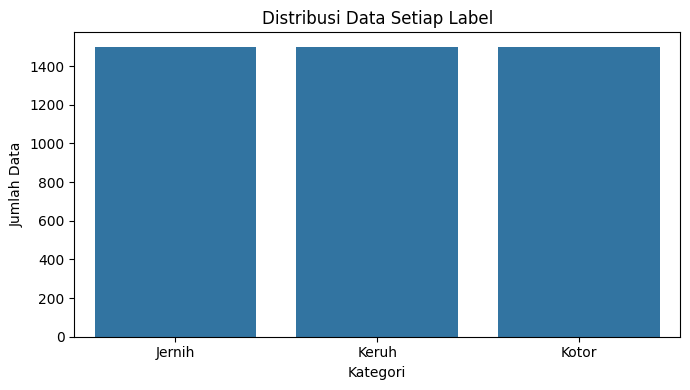

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="label", order=["Jernih", "Keruh", "Kotor"])
plt.title("Distribusi Data Setiap Label")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

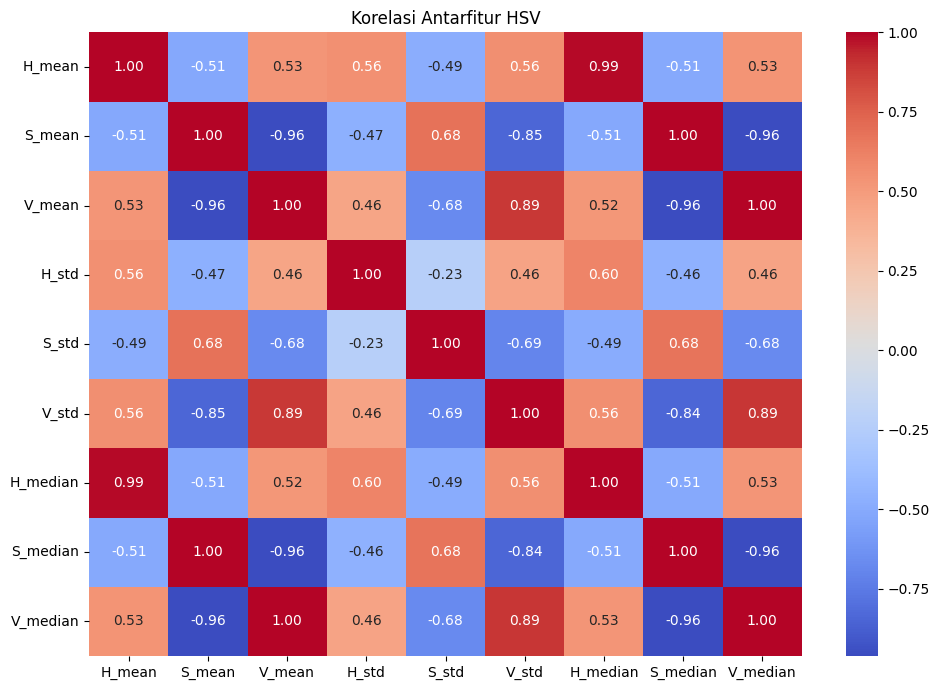

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[FITUR].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Antarfitur HSV")
plt.tight_layout()
plt.show()

## 8. Menentukan Fitur dan Target

Variabel `X` berisi sembilan fitur HSV, sedangkan variabel `y` berisi kategori kualitas air yang menjadi target klasifikasi.

In [13]:
X = df[FITUR].copy()
y = df["label"].copy()

print("Ukuran fitur X:", X.shape)
print("Ukuran target y:", y.shape)
print("\nDistribusi target:")
print(y.value_counts())

Ukuran fitur X: (4500, 9)
Ukuran target y: (4500,)

Distribusi target:
label
Keruh     1500
Kotor     1500
Jernih    1500
Name: count, dtype: int64


## 9. Pembagian Data Latih dan Data Uji

Dataset dibagi dengan rasio 80% data latih dan 20% data uji. Parameter `stratify=y` digunakan agar proporsi setiap kelas tetap seimbang pada kedua bagian data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))

print("\nDistribusi label data latih:")
print(y_train.value_counts())

print("\nDistribusi label data uji:")
print(y_test.value_counts())

Jumlah data latih: 3600
Jumlah data uji: 900

Distribusi label data latih:
label
Keruh     1200
Jernih    1200
Kotor     1200
Name: count, dtype: int64

Distribusi label data uji:
label
Kotor     300
Jernih    300
Keruh     300
Name: count, dtype: int64


## 10. Pembangunan Model Random Forest Awal

Model awal dibangun menggunakan 100 pohon keputusan. `class_weight="balanced"` digunakan untuk menyesuaikan bobot kelas apabila terdapat perbedaan jumlah data.

In [15]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf_awal = model_rf.predict(X_test)

print("Model Random Forest awal berhasil dilatih.")

Model Random Forest awal berhasil dilatih.


## 11. Evaluasi Random Forest Awal

Performa model diukur menggunakan akurasi, precision, recall, F1-score, classification report, dan confusion matrix.

In [16]:
akurasi_rf_awal = accuracy_score(y_test, y_pred_rf_awal)
precision_rf_awal = precision_score(
    y_test, y_pred_rf_awal, average="weighted", zero_division=0
)
recall_rf_awal = recall_score(
    y_test, y_pred_rf_awal, average="weighted", zero_division=0
)
f1_rf_awal = f1_score(
    y_test, y_pred_rf_awal, average="weighted", zero_division=0
)

print("Hasil Evaluasi Random Forest Awal")
print("=" * 42)
print(f"Akurasi   : {akurasi_rf_awal:.4f} ({akurasi_rf_awal * 100:.2f}%)")
print(f"Precision : {precision_rf_awal:.4f}")
print(f"Recall    : {recall_rf_awal:.4f}")
print(f"F1-Score  : {f1_rf_awal:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_awal, zero_division=0))

Hasil Evaluasi Random Forest Awal
Akurasi   : 0.9989 (99.89%)
Precision : 0.9989
Recall    : 0.9989
F1-Score  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Jernih       1.00      1.00      1.00       300
       Keruh       1.00      1.00      1.00       300
       Kotor       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



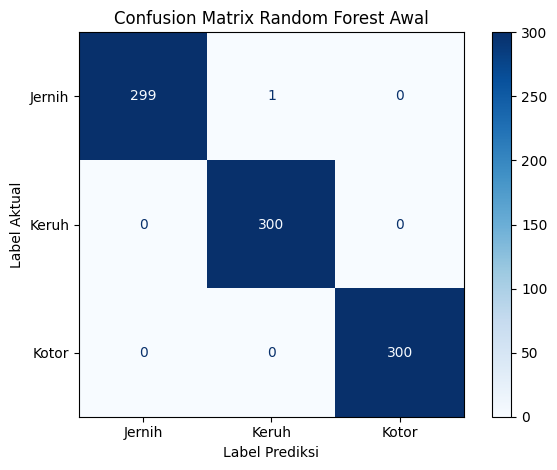

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_awal,
    labels=["Jernih", "Keruh", "Kotor"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix Random Forest Awal")
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.tight_layout()
plt.show()

## 12. Optimasi Hyperparameter Random Forest Menggunakan GridSearchCV

GridSearchCV mencoba sejumlah kombinasi parameter Random Forest. Validasi dilakukan menggunakan `StratifiedKFold` lima bagian dengan pengacakan agar pembagian data lebih konsisten dan tetap mempertahankan proporsi kelas.

In [18]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("\nParameter terbaik:")
print(grid_search.best_params_)

print("\nRata-rata akurasi cross-validation terbaik:")
print(f"{grid_search.best_score_:.6f} ({grid_search.best_score_ * 100:.2f}%)")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Parameter terbaik:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Rata-rata akurasi cross-validation terbaik:
0.998333 (99.83%)


## 13. Evaluasi Model Random Forest Terbaik

Model terbaik dari GridSearchCV diuji menggunakan data uji yang tidak digunakan dalam proses pencarian parameter.

In [21]:
model_terbaik = grid_search.best_estimator_
y_pred_terbaik = model_terbaik.predict(X_test)

akurasi_rf = accuracy_score(y_test, y_pred_terbaik)
precision_rf = precision_score(
    y_test, y_pred_terbaik, average="weighted", zero_division=0
)
recall_rf = recall_score(
    y_test, y_pred_terbaik, average="weighted", zero_division=0
)
f1_rf = f1_score(
    y_test, y_pred_terbaik, average="weighted", zero_division=0
)

print("Hasil Evaluasi Random Forest Terbaik")
print("=" * 45)
print(f"Akurasi   : {akurasi_rf:.4f} ({akurasi_rf * 100:.2f}%)")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_terbaik, zero_division=0))

Hasil Evaluasi Random Forest Terbaik
Akurasi   : 0.9989 (99.89%)
Precision : 0.9989
Recall    : 0.9989
F1-Score  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Jernih       1.00      1.00      1.00       300
       Keruh       1.00      1.00      1.00       300
       Kotor       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



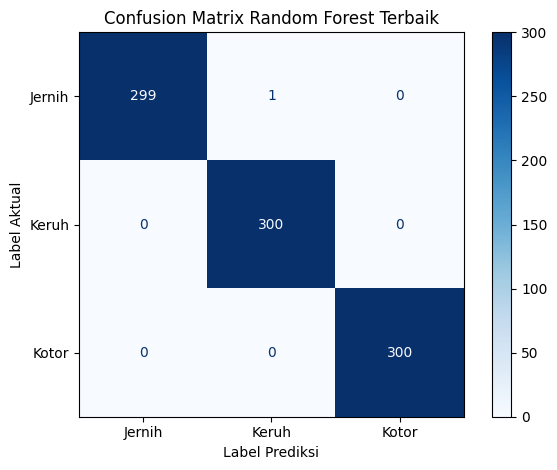

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_terbaik,
    labels=["Jernih", "Keruh", "Kotor"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix Random Forest Terbaik")
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.tight_layout()
plt.show()

## 14. Validasi Silang Random Forest Terbaik

Validasi silang lima bagian dilakukan pada seluruh subset untuk mengukur kestabilan performa model pada pembagian data yang berbeda.

In [23]:
cv_scores_rf = cross_val_score(
    model_terbaik,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("Akurasi setiap fold:", cv_scores_rf)
print(f"Rata-rata Cross Validation: {cv_scores_rf.mean():.6f}")
print(f"Standar Deviasi: {cv_scores_rf.std():.6f}")

Akurasi setiap fold: [1.         0.99666667 0.99777778 0.99888889 1.        ]
Rata-rata Cross Validation: 0.998667
Standar Deviasi: 0.001296


## 15. Pembangunan dan Evaluasi Decision Tree

Decision Tree digunakan sebagai model pembanding agar performanya dapat dibandingkan dengan Random Forest pada data yang sama.

In [24]:
model_dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

akurasi_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
)
recall_dt = recall_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
)
f1_dt = f1_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
)

print("Hasil Evaluasi Decision Tree")
print("=" * 38)
print(f"Akurasi   : {akurasi_dt:.4f} ({akurasi_dt * 100:.2f}%)")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Hasil Evaluasi Decision Tree
Akurasi   : 0.9978 (99.78%)
Precision : 0.9978
Recall    : 0.9978
F1-Score  : 0.9978

Classification Report:
              precision    recall  f1-score   support

      Jernih       1.00      1.00      1.00       300
       Keruh       0.99      1.00      1.00       300
       Kotor       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



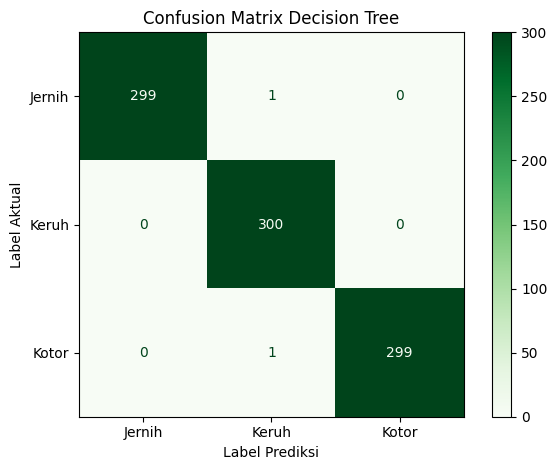

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    labels=["Jernih", "Keruh", "Kotor"],
    cmap="Greens",
    values_format="d"
)
plt.title("Confusion Matrix Decision Tree")
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.tight_layout()
plt.show()

In [26]:
cv_scores_dt = cross_val_score(
    model_dt,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("Decision Tree - Akurasi setiap fold:", cv_scores_dt)
print(f"Decision Tree - Rata-rata: {cv_scores_dt.mean():.6f}")
print(f"Decision Tree - Standar deviasi: {cv_scores_dt.std():.6f}")

Decision Tree - Akurasi setiap fold: [0.99888889 0.99555556 0.99555556 0.99555556 0.99777778]
Decision Tree - Rata-rata: 0.996667
Decision Tree - Standar deviasi: 0.001405


## 16. Perbandingan Model

Random Forest dan Decision Tree dibandingkan berdasarkan akurasi, precision, recall, F1-score, rata-rata cross-validation, dan standar deviasi cross-validation.

In [27]:
hasil_perbandingan = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree"],
    "Accuracy": [akurasi_rf, akurasi_dt],
    "Precision": [precision_rf, precision_dt],
    "Recall": [recall_rf, recall_dt],
    "F1-Score": [f1_rf, f1_dt],
    "CV Mean": [cv_scores_rf.mean(), cv_scores_dt.mean()],
    "CV Std": [cv_scores_rf.std(), cv_scores_dt.std()]
})

display(hasil_perbandingan.round(6))

,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Random Forest,0.998889,0.998893,0.998889,0.998889,0.998667,0.001296
1,Decision Tree,0.997778,0.997792,0.997778,0.997780,0.996667,0.001405


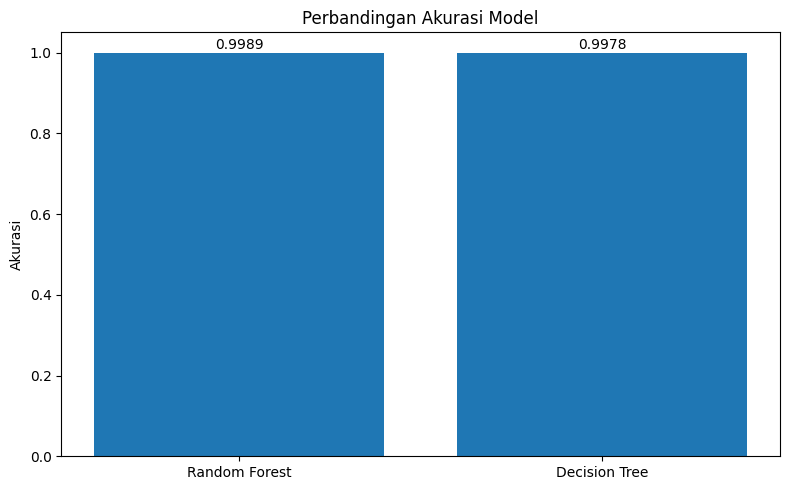

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(
    hasil_perbandingan["Model"],
    hasil_perbandingan["Accuracy"]
)
plt.ylabel("Akurasi")
plt.title("Perbandingan Akurasi Model")
plt.ylim(0, 1.05)

for index, nilai in enumerate(hasil_perbandingan["Accuracy"]):
    plt.text(index, nilai + 0.01, f"{nilai:.4f}", ha="center")

plt.tight_layout()
plt.show()

## 17. Feature Importance Random Forest

Feature importance menunjukkan besarnya kontribusi relatif setiap fitur HSV terhadap keputusan klasifikasi model Random Forest terbaik.

,Feature,Importance
1,S_mean,0.345442
2,V_mean,0.269864
7,S_median,0.131785
8,V_median,0.093442
0,H_mean,0.040151
3,H_std,0.039015
5,V_std,0.034919
6,H_median,0.027525
4,S_std,0.017856


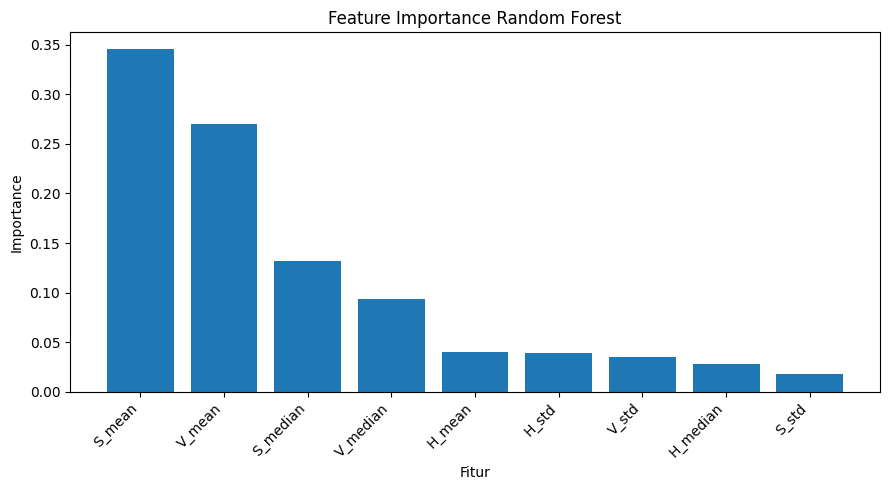

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_terbaik.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

plt.figure(figsize=(9, 5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance Random Forest")
plt.xlabel("Fitur")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 18. Menyimpan Model dan Informasi Fitur

Model Random Forest terbaik disimpan menggunakan Joblib agar dapat digunakan kembali pada aplikasi Streamlit tanpa melakukan pelatihan ulang.

In [30]:
MODEL_PATH = "model_air_hsv.pkl"
FEATURE_PATH = "fitur_model_hsv.pkl"

joblib.dump(model_terbaik, MODEL_PATH)
joblib.dump(FITUR, FEATURE_PATH)

print(f"Model berhasil disimpan sebagai {MODEL_PATH}")
print(f"Daftar fitur berhasil disimpan sebagai {FEATURE_PATH}")

Model berhasil disimpan sebagai model_air_hsv.pkl
Daftar fitur berhasil disimpan sebagai fitur_model_hsv.pkl


## 19. Pengujian Ulang Model yang Disimpan

Model dimuat kembali untuk memastikan file model dapat digunakan dan menghasilkan prediksi yang sama.

In [31]:
model_loaded = joblib.load(MODEL_PATH)
fitur_loaded = joblib.load(FEATURE_PATH)

contoh_data = X_test.iloc[[0]][fitur_loaded]
prediksi_contoh = model_loaded.predict(contoh_data)[0]
label_aktual = y_test.iloc[0]

print("Label aktual :", label_aktual)
print("Hasil prediksi:", prediksi_contoh)
display(contoh_data)

Label aktual : Kotor
Hasil prediksi: Kotor


,H_mean,S_mean,V_mean,H_std,S_std,V_std,H_median,S_median,V_median
718,16.94808,105.115912,131.172036,0.223232,2.939663,3.374874,17.0,106.0,130.0


## 20. Pembahasan dan Interpretasi Hasil

Hasil evaluasi perlu dijelaskan berdasarkan nilai yang benar-benar muncul setelah seluruh cell dijalankan. Akurasi yang sangat tinggi dapat terjadi karena dataset diperoleh dari kondisi pengambilan gambar yang terkontrol dan terdiri atas frame-frame yang memiliki karakteristik visual serupa. Fitur HSV juga memiliki hubungan langsung dengan perubahan warna dan tingkat kekeruhan air, sehingga pemisahan antarkelas dapat menjadi sangat mudah.

Walaupun subset telah dikurangi menjadi sekitar 4.500 data, pengurangan jumlah data tidak menjamin akurasi akan turun. Apabila distribusi fitur antarkelas tetap terpisah dengan jelas atau terdapat banyak frame yang hampir identik, model masih dapat memperoleh akurasi mendekati 100%.

Untuk menilai kemampuan generalisasi pada kondisi nyata, penelitian lanjutan dapat menggunakan pembagian data berdasarkan video atau sampel asal, menghapus frame yang terlalu mirip, dan menambahkan citra dari kondisi pencahayaan serta latar belakang yang lebih bervariasi.

## 21. Keterbatasan Penelitian

1. Dataset citra diperoleh dalam kondisi yang relatif terkontrol sehingga belum sepenuhnya mewakili kondisi air di lingkungan nyata.
2. Beberapa gambar dapat berupa frame yang berdekatan dari video yang sama sehingga memiliki kemiripan visual yang tinggi.
3. Label kualitas air dibentuk dari penggabungan lima kelas asli menjadi tiga kategori penelitian.
4. Model hanya menggunakan statistik warna HSV dan belum menggunakan fitur tekstur, bentuk, maupun parameter kimia air.
5. Pembagian data dilakukan secara acak per gambar dan belum berdasarkan video atau sampel asal.
6. Pengurangan dataset menjadi subset seimbang bertujuan menyeimbangkan kelas dan mempercepat proses, bukan untuk memanipulasi nilai akurasi.

In [34]:
model_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="minkowski",
        p=2
    ))
])

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print("Model KNN berhasil dilatih.")

Model KNN berhasil dilatih.


In [35]:
akurasi_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

print("Hasil Evaluasi KNN")
print("=" * 40)

print(f"Akurasi   : {akurasi_knn:.4f}")
print(f"Persentase: {akurasi_knn * 100:.2f}%")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"F1-Score  : {f1_knn:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn,
        zero_division=0
    )
)

Hasil Evaluasi KNN
Akurasi   : 0.9978
Persentase: 99.78%
Precision : 0.9978
Recall    : 0.9978
F1-Score  : 0.9978

Classification Report:
              precision    recall  f1-score   support

      Jernih       1.00      0.99      1.00       300
       Keruh       0.99      1.00      1.00       300
       Kotor       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [36]:
cv_scores_knn = cross_val_score(
    model_knn,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("Akurasi setiap fold:")
print(cv_scores_knn)

print(
    f"\nRata-rata Cross Validation: "
    f"{cv_scores_knn.mean():.6f}"
)

print(
    f"Standar Deviasi: "
    f"{cv_scores_knn.std():.6f}"
)

Akurasi setiap fold:
[0.99777778 0.99666667 0.99888889 0.99666667 0.99666667]

Rata-rata Cross Validation: 0.997333
Standar Deviasi: 0.000889


In [37]:
param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_knn = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    param_grid=param_grid_knn,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train, y_train)

print("Parameter KNN terbaik:")
print(grid_knn.best_params_)

print("\nAkurasi cross-validation terbaik:")
print(
    f"{grid_knn.best_score_:.6f} "
    f"({grid_knn.best_score_ * 100:.2f}%)"
)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Parameter KNN terbaik:
{'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}

Akurasi cross-validation terbaik:
0.999444 (99.94%)


In [38]:
model_knn_terbaik = grid_knn.best_estimator_

y_pred_knn_terbaik = model_knn_terbaik.predict(X_test)

akurasi_knn_terbaik = accuracy_score(
    y_test,
    y_pred_knn_terbaik
)

precision_knn_terbaik = precision_score(
    y_test,
    y_pred_knn_terbaik,
    average="weighted",
    zero_division=0
)

recall_knn_terbaik = recall_score(
    y_test,
    y_pred_knn_terbaik,
    average="weighted",
    zero_division=0
)

f1_knn_terbaik = f1_score(
    y_test,
    y_pred_knn_terbaik,
    average="weighted",
    zero_division=0
)

print("Hasil Evaluasi KNN Terbaik")
print("=" * 40)

print(
    f"Akurasi   : {akurasi_knn_terbaik:.4f} "
    f"({akurasi_knn_terbaik * 100:.2f}%)"
)

print(f"Precision : {precision_knn_terbaik:.4f}")
print(f"Recall    : {recall_knn_terbaik:.4f}")
print(f"F1-Score  : {f1_knn_terbaik:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn_terbaik,
        zero_division=0
    )
)

Hasil Evaluasi KNN Terbaik
Akurasi   : 0.9989 (99.89%)
Precision : 0.9989
Recall    : 0.9989
F1-Score  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Jernih       1.00      1.00      1.00       300
       Keruh       1.00      1.00      1.00       300
       Kotor       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [39]:
hasil_perbandingan = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "K-Nearest Neighbor"
    ],
    "Accuracy": [
        akurasi_rf,
        akurasi_dt,
        akurasi_knn_terbaik
    ],
    "Precision": [
        precision_rf,
        precision_dt,
        precision_knn_terbaik
    ],
    "Recall": [
        recall_rf,
        recall_dt,
        recall_knn_terbaik
    ],
    "F1-Score": [
        f1_rf,
        f1_dt,
        f1_knn_terbaik
    ]
})

display(hasil_perbandingan.round(6))

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.998889,0.998893,0.998889,0.998889
1,Decision Tree,0.997778,0.997792,0.997778,0.997780
2,K-Nearest Neighbor,0.998889,0.998893,0.998889,0.998889
